<a href="https://colab.research.google.com/github/gouri25m-cpu/Machinelearning-Projects/blob/main/bangalurhousepriceprediction/blrhouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Bengaluru_House_Data (6).csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df.drop("society",axis=1,inplace=True)

In [ ]:
df.dropna(subset=["location"],inplace=True)

In [ ]:
df.dropna(subset=["size"],inplace=True)

<Axes: >

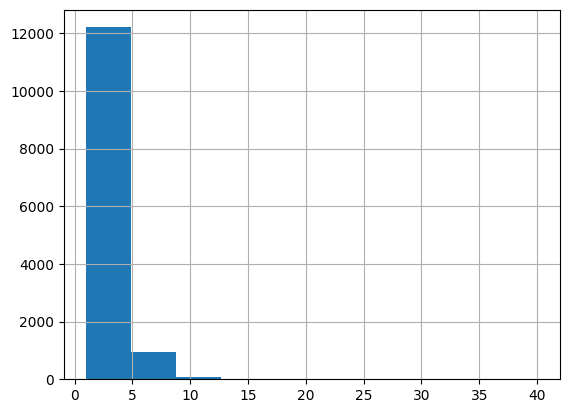

In [ ]:
df["bath"].hist()

<Axes: >

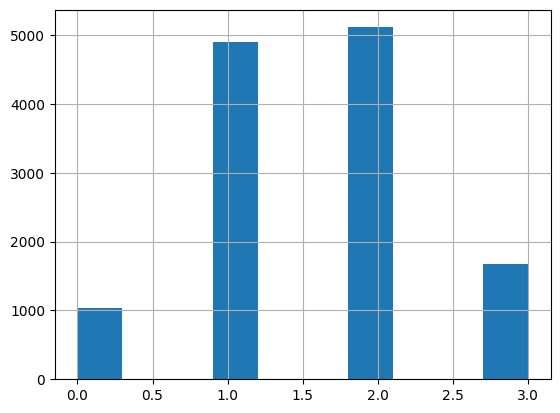

In [ ]:
df["balcony"].hist()

In [ ]:
df["bath"].fillna(df["bath"].median(),inplace=True)

/tmp/ipykernel_5284/657934831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bath"].fillna(df["bath"].median(),inplace=True)


In [ ]:
df["balcony"].fillna(df["balcony"].median(),inplace=True)

/tmp/ipykernel_5284/3079995741.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["balcony"].fillna(df["balcony"].median(),inplace=True)


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [ ]:
print(df['location'].unique())

['Electronic City Phase II' 'Chikka Tirupathi' 'Uttarahalli' ...
 '12th cross srinivas nagar banshankari 3rd stage' 'Havanur extension'
 'Abshot Layout']


In [ ]:
df['location'].value_counts()

,count
location,
Whitefield,539
Sarjapur Road,397
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
KAMAKIYA,1
Wheelers Road,1
MM Layout,1


In [ ]:
df.duplicated().sum()

np.int64(569)

In [ ]:
df.shape

(13303, 8)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(12734, 8)

(array([1.2235e+04, 3.9600e+02, 6.0000e+01, 1.3000e+01, 1.0000e+01,
        9.0000e+00, 4.0000e+00, 5.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([   8. ,  367.2,  726.4, 1085.6, 1444.8, 1804. , 2163.2, 2522.4,
        2881.6, 3240.8, 3600. ]),
 <BarContainer object of 10 artists>)

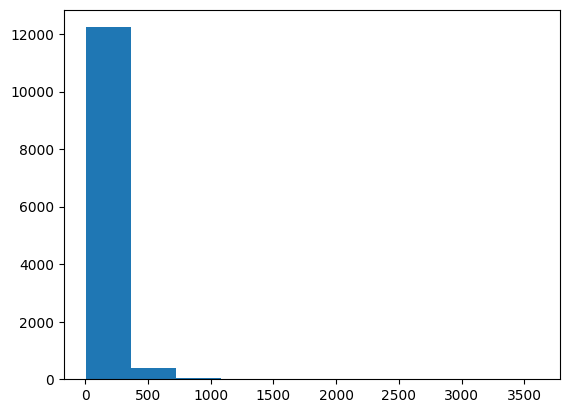

In [ ]:
plt.hist(df["price"])

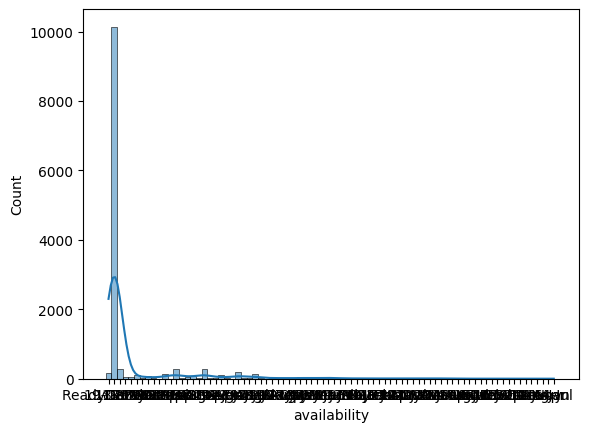

In [ ]:
sns.histplot(df['availability'],kde=True)
plt.show()

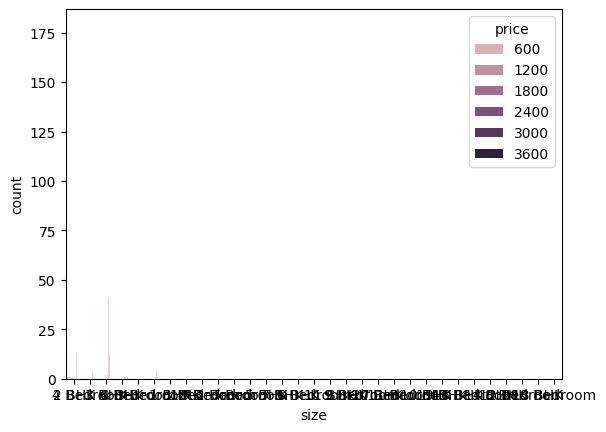

In [ ]:
sns.countplot(data=df,x='size',hue='price')
plt.show()

In [ ]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12734 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12734 non-null  object 
 1   availability  12734 non-null  object 
 2   location      12734 non-null  object 
 3   size          12734 non-null  object 
 4   total_sqft    12734 non-null  object 
 5   bath          12734 non-null  float64
 6   balcony       12734 non-null  float64
 7   price         12734 non-null  float64
dtypes: float64(3), object(5)
memory usage: 895.4+ KB


In [ ]:
df

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,2.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['area_type']=le.fit_transform(df['area_type'])
df['availability']=le.fit_transform(df['availability'])
df['location']=le.fit_transform(df ['area_type'])
df['size']=le.fit_transform(df['size'])


In [ ]:
df

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,3,40,3,13,1056,2.0,1.0,39.07
1,2,79,2,19,2600,5.0,3.0,120.00
2,0,79,0,16,1440,2.0,3.0,62.00
3,3,79,3,16,1521,3.0,1.0,95.00
4,3,79,3,13,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13314,3,79,3,16,1715,3.0,3.0,112.00
13315,0,79,0,22,3453,4.0,0.0,231.00
13316,3,79,3,18,3600,5.0,2.0,400.00
13317,0,79,0,13,1141,2.0,1.0,60.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12734 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12734 non-null  int64  
 1   availability  12734 non-null  int64  
 2   location      12734 non-null  int64  
 3   size          12734 non-null  int64  
 4   total_sqft    12734 non-null  object 
 5   bath          12734 non-null  float64
 6   balcony       12734 non-null  float64
 7   price         12734 non-null  float64
dtypes: float64(3), int64(4), object(1)
memory usage: 895.4+ KB


In [ ]:
df['total_sqft']=pd.to_numeric(df['total_sqft'],errors="coerce")

In [ ]:
df["total_sqft"].fillna(df["total_sqft"].median(),inplace=True)

/tmp/ipykernel_5284/3681608186.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_sqft"].fillna(df["total_sqft"].median(),inplace=True)


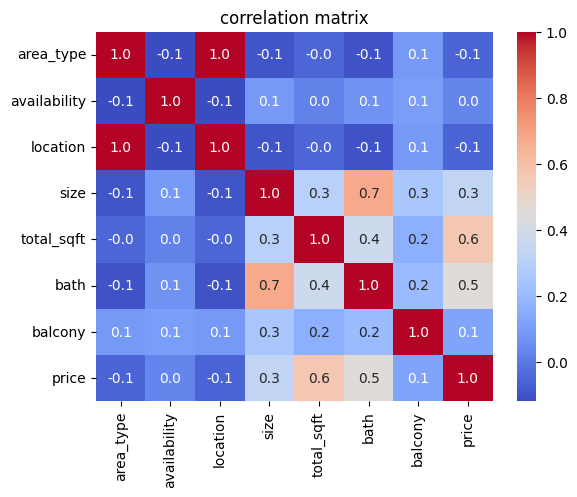

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(["area_type"],axis=1,inplace=True)

In [ ]:
df

,availability,location,size,total_sqft,bath,balcony,price
0,40,3,13,1056.0,2.0,1.0,39.07
1,79,2,19,2600.0,5.0,3.0,120.00
2,79,0,16,1440.0,2.0,3.0,62.00
3,79,3,16,1521.0,3.0,1.0,95.00
4,79,3,13,1200.0,2.0,1.0,51.00
...,...,...,...,...,...,...,...
13314,79,3,16,1715.0,3.0,3.0,112.00
13315,79,0,22,3453.0,4.0,0.0,231.00
13316,79,3,18,3600.0,5.0,2.0,400.00
13317,79,0,13,1141.0,2.0,1.0,60.00


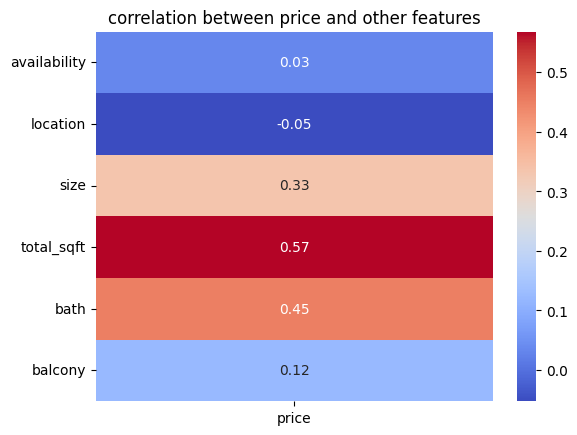

In [ ]:
price_corr=df.corr()['price']
price_corr=price_corr.drop('price')
sns.heatmap(price_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':10})
plt.title('correlation between price and other features')
plt.show()

In [ ]:
df.drop(["availability","location"],axis=1,inplace=True)

<Axes: >

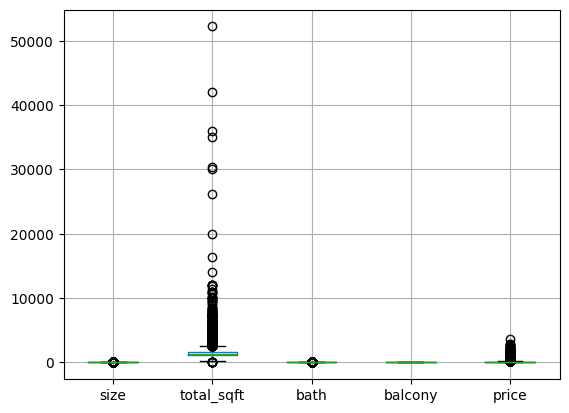

In [ ]:
df.boxplot()

In [ ]:
def remove_outlires_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
       continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df
df_cleaned=remove_outlires_iqr(df,exclude_column='price')
df=df_cleaned


In [ ]:
df.shape

(10185, 5)

In [ ]:
df

,size,total_sqft,bath,balcony,price
0,13,1056.0,2.0,1.0,39.07
2,16,1440.0,2.0,3.0,62.00
3,16,1521.0,3.0,1.0,95.00
4,13,1200.0,2.0,1.0,51.00
5,13,1170.0,2.0,1.0,38.00
...,...,...,...,...,...
13309,16,1675.0,3.0,2.0,92.13
13310,13,1050.0,2.0,2.0,52.71
13312,13,1262.0,2.0,2.0,47.00
13314,16,1715.0,3.0,3.0,112.00


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['size','total_sqft','bath','balcony']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd
x=df[['size','total_sqft','bath','balcony']]
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.38
